# Импорт библиотек

In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from skopt import BayesSearchCV
from scipy.stats import uniform, randint
from skopt.space import Real, Integer

# Код из 4 лабы

In [65]:
path = r"F:\\VSCODE_PROJECT\\ML_Proga\\LAB_3\\smartphone_battery_processed.csv"
df = pd.read_csv(path)
target = "Battery_Drop_Per_Hour"
cols_to_keep = [
    "App_Running",
    "Screen_On_Time_min",
    "CPU_Usage_%",
    "Battery_Temperature_C",
    target,
    "Network_Type",
    "Brightness_Level_%",
    "RAM_Usage_MB",
    "Charging_State",
    "Usage_Mode",
    "Intensity",
    "High_Temperature",
]
df = df[cols_to_keep]
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cat_cols = ["App_Running", "Network_Type", "Charging_State", "Usage_Mode"]
num_cols = ["Screen_On_Time_min", "Battery_Temperature_C", "Intensity", "High_Temperature"]
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(X_train[cat_cols])
scaler = StandardScaler().fit(X_train[num_cols])
def transform_data(data):
    cat = pd.DataFrame(ohe.transform(data[cat_cols]), columns=ohe.get_feature_names_out(), index=data.index)
    num = pd.DataFrame(scaler.transform(data[num_cols]), columns=num_cols, index=data.index)
    return pd.concat([num, cat], axis=1)
X_train_f = transform_data(X_train)
X_test_f = transform_data(X_test)

# Вывод корреляций 

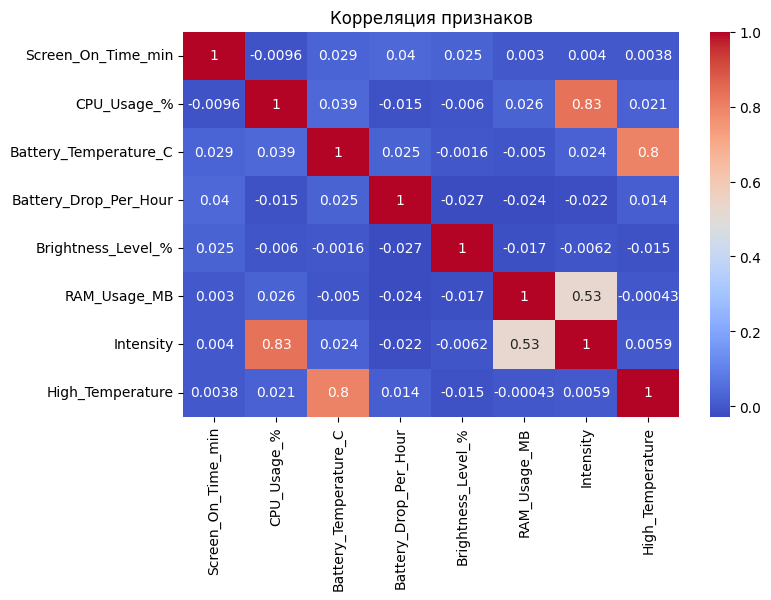

In [66]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap="coolwarm")
plt.title("Корреляция признаков")
plt.show()

# Лабораторная номер 5

Диапозон гиперпараметров

In [67]:
#для Байесовского поиска
search_spaces = {
    "n_estimators": [100, 200, 300],
    "learning_rate": (0.01, 0.1),
    "max_depth": [3, 5, 7, 10],
    "subsample": (0.6, 1.0),
}

rf_bayes_space = {
    'n_estimators': [100, 200, 300],
    'max_depth': (3, 15),
    'min_samples_split': (2, 10),
}

# для Random Search
random_search_params_xgb = {
    'learning_rate': uniform(0.01, 0.1),
    'max_depth': randint(3, 10),
    'n_estimators': randint(100, 500),
    'subsample': uniform(0.5, 0.5)
}

random_search_params_rf = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 11)
}

# для Grid
simple_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.6, 0.8, 1.0],#  выбирать для каждого шага обучения(дерева) только  n-ый % кол-ва строк (строки перемешиваются случайно)
}

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5, 10]
}

Функция для поиска гиперпараметров

In [68]:
results_list = []


def run_experiment(name,model_name, search_obj):
    start_time = time.time()
    search_obj.fit(X_train_f, y_train)
    end_time = time.time() - start_time

    best_model = search_obj.best_estimator_
    y_pred = best_model.predict(X_test_f)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results_list.append(
        {
            'Model': model_name,
            "Method": name,
            "Time_sec": end_time,
            "R2": r2,
            "MSE": mse,
            "MAE": mae,
            "Best_Params": search_obj.best_params_,
        }
    )
    print(f"Время: {end_time:.2f}с")

Поиск решёткой

In [69]:
run_experiment(
    "Grid Search",'XGBoost',
    GridSearchCV(
        XGBRegressor(random_state=42), simple_param_grid, cv=3, n_jobs=-1, scoring="r2" # cv - кросс валидация, n_jobs=-1 - использую все ядра(для мака)
    ),
)

run_experiment('Grid Search', 'Random Forest',
               GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=3, n_jobs=-1))


Время: 25.51с
Время: 8.31с


Случайный поиск

In [70]:
run_experiment(
    "Random Search",'XGBoost',
    RandomizedSearchCV(
        XGBRegressor(random_state=42),
        random_search_params_xgb,
        n_iter=30, # n_iter=10 - количество попыток
        cv=3,
        n_jobs=-1,
        scoring="r2",
        random_state=42,
    ),
)

run_experiment('Random Search','Random Forest',
               RandomizedSearchCV(RandomForestRegressor(random_state=42), random_search_params_rf , n_iter=30, cv=3, n_jobs=-1, random_state=42))

Время: 7.94с
Время: 20.88с


Байсовский метод

In [71]:
run_experiment(
    "Bayesian Search",'XGBoost',
    BayesSearchCV(
        XGBRegressor(random_state=42),
        search_spaces,
        n_iter=15,
        cv=3,
        n_jobs=-1,
        scoring="r2",
        random_state=42,
    ),
)

run_experiment('Bayesian Search', 'Random Forest',
               BayesSearchCV(RandomForestRegressor(random_state=42), rf_bayes_space, n_iter=15, cv=3, n_jobs=-1, random_state=42))

Время: 10.31с
Время: 14.43с


Вывод метрик 

In [72]:
df_res = pd.DataFrame(results_list)

for index, row in df_res.iterrows():
    print(f"\nМетод: {row['Method']} {row["Model"]}")
    print(f"Лучший R2: {row['R2']:.4f}")
    print(f"MSE: {row["MSE"]}")
    print(f"MAE: {row["MAE"]}")
    print(f"Время поиска {row["Time_sec"]}")
    print("Гиперпараметры")
    for param, value in row["Best_Params"].items():
        print(f"  {param}: {value}")



Метод: Grid Search XGBoost
Лучший R2: 0.0020
MSE: 24.672705885897525
MAE: 3.977718310235801
Время поиска 25.509129524230957
Гиперпараметры
  learning_rate: 0.01
  max_depth: 5
  n_estimators: 100
  subsample: 0.6

Метод: Grid Search Random Forest
Лучший R2: 0.0003
MSE: 24.712809246074336
MAE: 3.987523199738858
Время поиска 8.312919855117798
Гиперпараметры
  max_depth: 5
  min_samples_split: 2
  n_estimators: 200

Метод: Random Search XGBoost
Лучший R2: -0.0045
MSE: 24.833306181162147
MAE: 3.9974660840090253
Время поиска 7.941830635070801
Гиперпараметры
  learning_rate: 0.014612485008283152
  max_depth: 5
  n_estimators: 158
  subsample: 0.6999304858576277

Метод: Random Search Random Forest
Лучший R2: 0.0010
MSE: 24.695612096330716
MAE: 3.985665231071251
Время поиска 20.879671096801758
Гиперпараметры
  max_depth: 4
  min_samples_leaf: 1
  min_samples_split: 8
  n_estimators: 161

Метод: Bayesian Search XGBoost
Лучший R2: 0.0020
MSE: 24.672705885897525
MAE: 3.977718310235801
Время поис

График метрик и методов

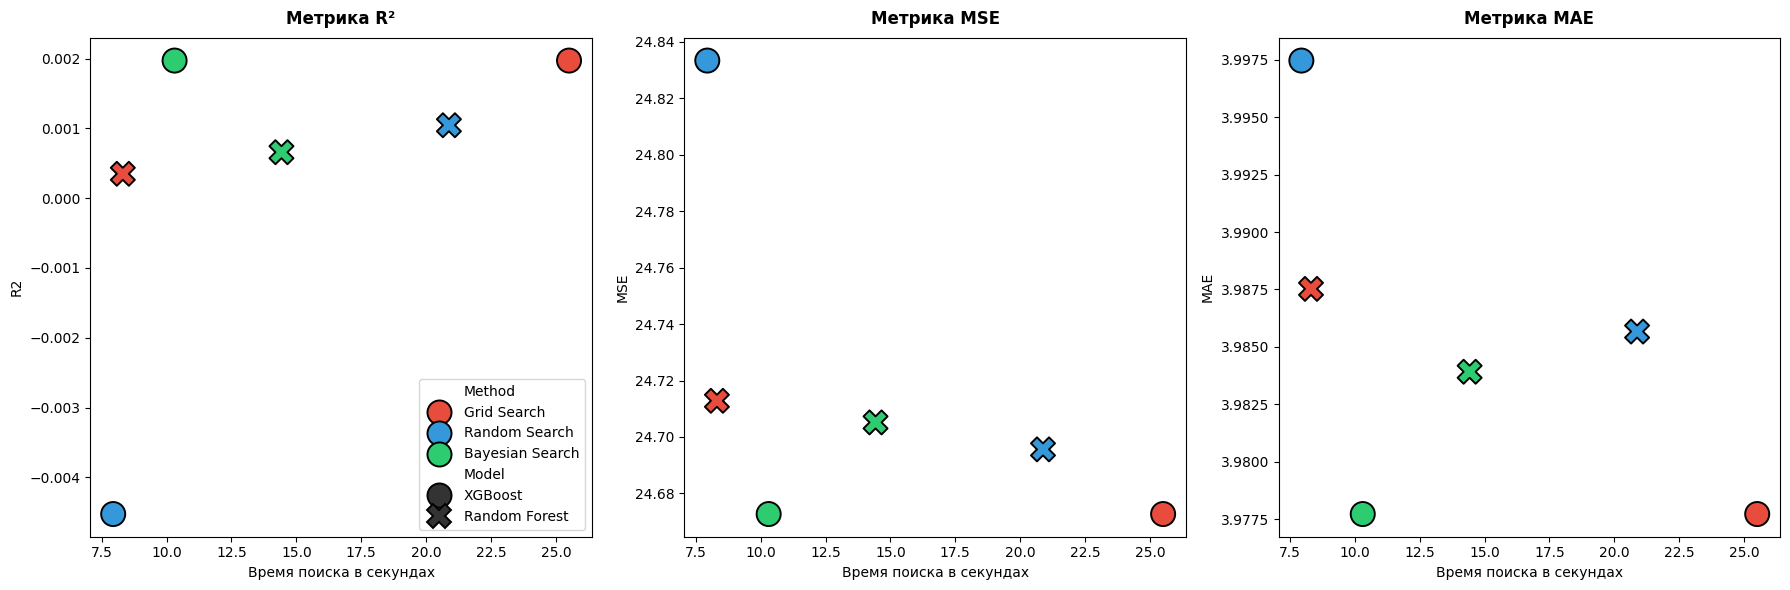

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['R2', 'MSE', 'MAE']
titles = [
    'Метрика R²',
    'Метрика MSE',
    'Метрика MAE'
]

for i, ax in enumerate(axes):
    metric = metrics[i]

    sns.scatterplot(
        data=df_res,
        x='Time_sec',
        y=metric,
        hue='Method',
        style='Model',
        s=300,
        ax=ax,
        palette=['#e74c3c', '#3498db', '#2ecc71'],
        edgecolor='black',
        legend=(i==0)
    )

    ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Время поиска в секундах', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)

plt.tight_layout()
plt.show()